# Solving a Red-Wine Classification Problem with Random Forest Classifier

In [89]:
# Import essential Libaries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,classification_report, roc_auc_score

In [90]:
# Load the Dataset(Direct from UCI)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep = ';') # ';' is the delimiter

In [91]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [93]:
df['quality'].describe()

count    1599.000000
mean        5.636023
std         0.807569
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64

## Create A Binary Classification Proble Good(7-10) vs Not Good

In [94]:
df['target'] = (df['quality']>=7).astype(int)
df.drop('quality',axis =1, inplace = True)
print(df['target'].value_counts())

target
0    1382
1     217
Name: count, dtype: int64


In [95]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


## Split into train and test

In [96]:
X = df.drop('target',axis=1)
y=df['target']

In [97]:
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size = 0.3, random_state = 42, stratify =y)

## Build a Basic Random Forest Model

In [98]:
rf = RandomForestClassifier(
    n_estimators = 100, #number of trees
    max_depth = None, #No limit on Depth
    max_features='sqrt',# Root of p feature at each slipt
    random_state = 42,
    oob_score = True  # Enable out-of-bag score
)

In [99]:
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


## Check out Out-Of-Bag Score (an internal cross-validation metric)

In [100]:
print("OOB score :", rf.oob_score_)

OOB score : 0.8936550491510277


In [101]:
# Indicates generalization ability without external Cross Validation metric

## Make Predections

In [102]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:,1] #Probabilities for ROC-AUC

## Evaluate Model

In [103]:
print("Classification Report\n :", classification_report(y_test,y_pred))

Classification Report
 :               precision    recall  f1-score   support

           0       0.93      0.99      0.96       415
           1       0.92      0.51      0.65        65

    accuracy                           0.93       480
   macro avg       0.92      0.75      0.81       480
weighted avg       0.93      0.93      0.92       480



In [104]:
print("ROC-AUC Score:",roc_auc_score(y_test,y_proba))

ROC-AUC Score: 0.9396292863762743


## Confusion Matrix

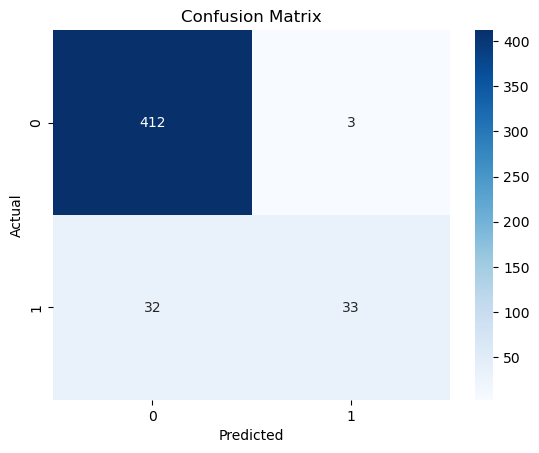

In [105]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Imporved model using class_weight = "balanced"

In [106]:
rf_balanced = RandomForestClassifier(n_estimators = 100, random_state = 42, class_weight = "balanced")
rf_balanced.fit(X_train,y_train)
y_pred_balanced = rf_balanced.predict(X_test)

print("Classification Report (Balanced Class Weight):")
print(classification_report(y_test, y_pred_balanced))

Classification Report (Balanced Class Weight):
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       415
           1       0.89      0.51      0.65        65

    accuracy                           0.93       480
   macro avg       0.91      0.75      0.80       480
weighted avg       0.92      0.93      0.92       480



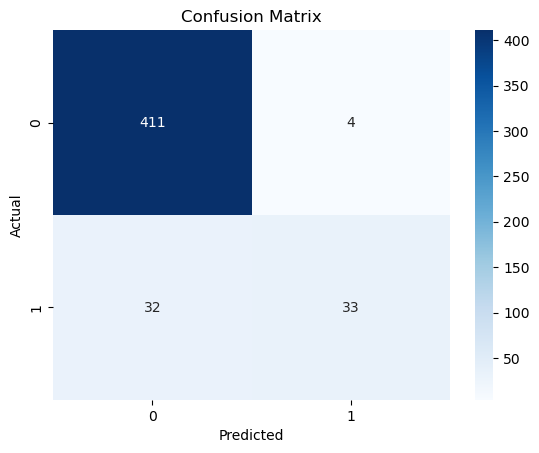

In [107]:
cm = confusion_matrix(y_test,y_pred_balanced)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [108]:
print(confusion_matrix(y_test,y_pred_balanced))

[[411   4]
 [ 32  33]]


In [109]:
# Compare recall for class 1

from sklearn.metrics import recall_score

recall_orig = recall_score(y_test,y_pred)
recall_bal = recall_score(y_test,y_pred_balanced)

print(f"Recall - Original Model :{recall_orig:.2f}")
print(f"Recall - Balanced Class Weights :{recall_bal:.2f}")

Recall - Original Model :0.51
Recall - Balanced Class Weights :0.51


## Threshold Tuning(Recommended Next)

In [110]:
from sklearn.metrics import precision_recall_curve

y_probs = rf.predict_proba(X_test)[:,1]

## Plot precision-recall curve to choose a better threshold

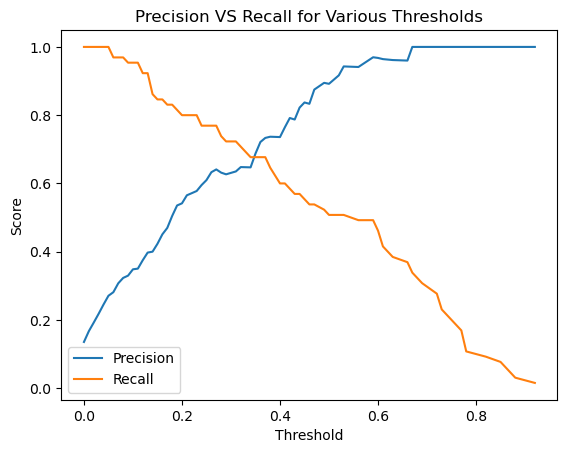

In [111]:
precision, recall , thresholds = precision_recall_curve(y_test,y_probs)
plt.plot(thresholds, precision[:-1], label = "Precision")
plt.plot(thresholds, recall[:-1], label = "Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision VS Recall for Various Thresholds")
plt.legend()
plt.show()


In [112]:
y_pred_thresh = (y_probs > 0.30).astype(int)

print("New Classification Report (Threshold = 0.3):")
print(classification_report(y_test,y_pred_thresh))

New Classification Report (Threshold = 0.3):
              precision    recall  f1-score   support

           0       0.96      0.93      0.95       415
           1       0.64      0.72      0.68        65

    accuracy                           0.91       480
   macro avg       0.80      0.83      0.81       480
weighted avg       0.91      0.91      0.91       480



## Feature Importance Visualization

In [113]:
importances = rf.feature_importances_
feat_importances = pd.Series(importances, index= X.columns).sort_values(ascending = False)

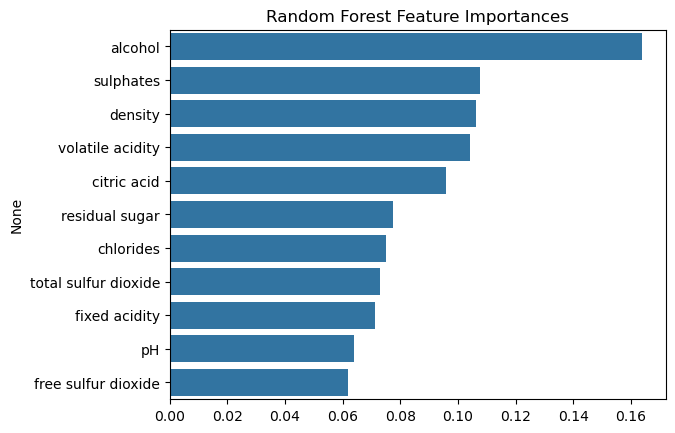

In [114]:
sns.barplot(x = feat_importances.values, y = feat_importances.index)
plt.title("Random Forest Feature Importances")
plt.show()

In [115]:
## Hyperparameter Tuning with GridSearchCV

param_grid = {
    "n_estimators": [100,200],
    "max_depth": [None, 10, 20],
    "min_samples_split":[2,5],
}

In [116]:
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv = 3, scoring = "roc_auc", n_jobs = -1)
grid.fit(X_train, y_train)
print("Best Params :", grid.best_params_)
print("best AUC(CV):", grid.best_score_)

Best Params : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
best AUC(CV): 0.8687450083008031


## SMOTE & Resampling Techniques

In [117]:
print(df['target'].value_counts())

target
0    1382
1     217
Name: count, dtype: int64


In [118]:
#Installing Imbalance learn library
#!pip install imbalanced-learn

In [119]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,0
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,0
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,0


In [121]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [122]:
#Define Features and target
X = df.drop('target', axis =1) # No 'quality' column in the current dataset
y = df['target']


In [123]:
#Train Test Split
X_train,X_test,y_train,y_test = train_test_split(X,y, stratify = y, random_state =42)

In [124]:
# Apply SMOTE to training data
sm = SMOTE(random_state = 42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

In [125]:
#Check class balance
print(pd.Series(y_train_sm).value_counts())

target
0    1036
1    1036
Name: count, dtype: int64


In [126]:
model_smote = RandomForestClassifier(random_state =42)
model_smote.fit(X_train_sm,y_train_sm)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [127]:
#Predict
y_pred_smote = model_smote.predict(X_test)

In [128]:
#Evaluate
print(classification_report(y_test,y_pred_smote))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       346
           1       0.62      0.70      0.66        54

    accuracy                           0.90       400
   macro avg       0.79      0.82      0.80       400
weighted avg       0.91      0.90      0.90       400

